In [28]:
# imports
import importlib
import models.hybrid_v2
import models.hybrid_v1
import models.hybrid_v3
import utils.plotting
import utils.losses
importlib.reload(models.hybrid_v2)
importlib.reload(models.hybrid_v1)
importlib.reload(models.hybrid_v3)
importlib.reload(utils.plotting)
importlib.reload(utils.losses)

<module 'utils.losses' from 'c:\\Users\\ARKA ROY\\Downloads\\option price project\\utils\\losses.py'>

In [29]:
import pandas as pd
import numpy as np

from utils.losses import custom_loss
from models.hybrid_v3 import HybridNetV3
from models.hybrid_v1 import HybridNetV1
from models.hybrid_v2 import HybridNetV2

import torch.optim as optim


In [30]:
# load data
DATA_FILE = "data/processed/AsianPaints_Model_Data_2019_24.csv"
df = pd.read_csv(DATA_FILE)

# PREPROCESSING 

In [31]:
# =========================
# DATA CLEANING + FEATURES
# =========================

from prepare_model_data import FEATURE_COLUMNS

# Choose training fraction here
train_size = 0.70

# Dataset is already model-ready from prepare_model_data.py
df = df.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna().sort_values("Date").reset_index(drop=True)

if not 0 < train_size < 1:
    raise ValueError("train_size must be between 0 and 1, e.g. 0.70")

split_idx = max(1, min(len(df) - 1, int(np.ceil(len(df) * train_size))))
split_date = df.iloc[split_idx - 1]["Date"]

features = FEATURE_COLUMNS.copy()

print(f"Train size target: {train_size:.0%}")
print(f"Computed split date: {split_date.date()}")

Train size target: 70%
Computed split date: 2022-10-07


In [32]:
from sklearn.preprocessing import StandardScaler

import torch
# TRAIN SPLIT
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train rows: {len(train_df):,} ({len(train_df) / len(df):.2%})")
print(f"Test rows: {len(test_df):,} ({len(test_df) / len(df):.2%})")

# SCALING (FIT ONLY ON TRAIN)
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_full = scaler.transform(df[features])

y_train = train_df["Market_Price"].values
bs_train = train_df["bs_price"].values

bs_full = df["bs_price"].values

# TENSORS
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
bs_train = torch.tensor(bs_train, dtype=torch.float32)

X_full = torch.tensor(X_full, dtype=torch.float32)
bs_full = torch.tensor(bs_full, dtype=torch.float32)

Train rows: 148,641 (70.00%)
Test rows: 63,702 (30.00%)


# MODEL FITTING

##### Fitting model to full data for plots

In [33]:
#change which model to train here

model_name = "HybridNetV3"  # or "OtherModel"

sigma_index = features.index("sigma")

model = HybridNetV3(input_dim=len(features),sigma_index=sigma_index)

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 1024

for epoch in range(epochs):
    model.train()
    
    perm = torch.randperm(X_train.size(0))
    total_loss = 0
    
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        
        xb = X_train[idx]
        yb = y_train[idx]
        bsb = bs_train[idx]
        
        optimizer.zero_grad()
        
        hybrid, alpha, log_error = model(xb, bsb)
        
        loss = custom_loss(hybrid, yb, alpha, log_error, bsb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss:.4f}")

Epoch 0 | Loss: 562399.8803
Epoch 5 | Loss: 92951.7850
Epoch 10 | Loss: 75718.6836
Epoch 15 | Loss: 74738.4002
Epoch 20 | Loss: 53505.5254
Epoch 25 | Loss: 46495.7583
Epoch 30 | Loss: 33440.4962
Epoch 35 | Loss: 34663.3165
Epoch 40 | Loss: 37644.6968
Epoch 45 | Loss: 37294.4222


In [34]:
model.eval()

with torch.no_grad():
    hybrid_pred, alpha_pred, log_error_pred = model(X_full, bs_full)

# Convert to numpy
hybrid_pred = hybrid_pred.detach().cpu().numpy().flatten()
alpha_pred = alpha_pred.detach().cpu().numpy().flatten()
log_error_pred = log_error_pred.detach().cpu().numpy().flatten()

bs_np = bs_full.detach().cpu().numpy()

# ML price
ml_price = bs_np * np.exp(log_error_pred)

# Attach to df
df = df.copy()
df["ml_price"] = ml_price
df["alpha"] = alpha_pred
df["hybrid_price"] = hybrid_pred

# Errors
df["bs_error"] = df["Market_Price"] - df["bs_price"]
df["hybrid_error"] = df["Market_Price"] - df["hybrid_price"]


# VISUALIZATION

c:\Users\ARKA ROY\Downloads\option price project\utils\plotting.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


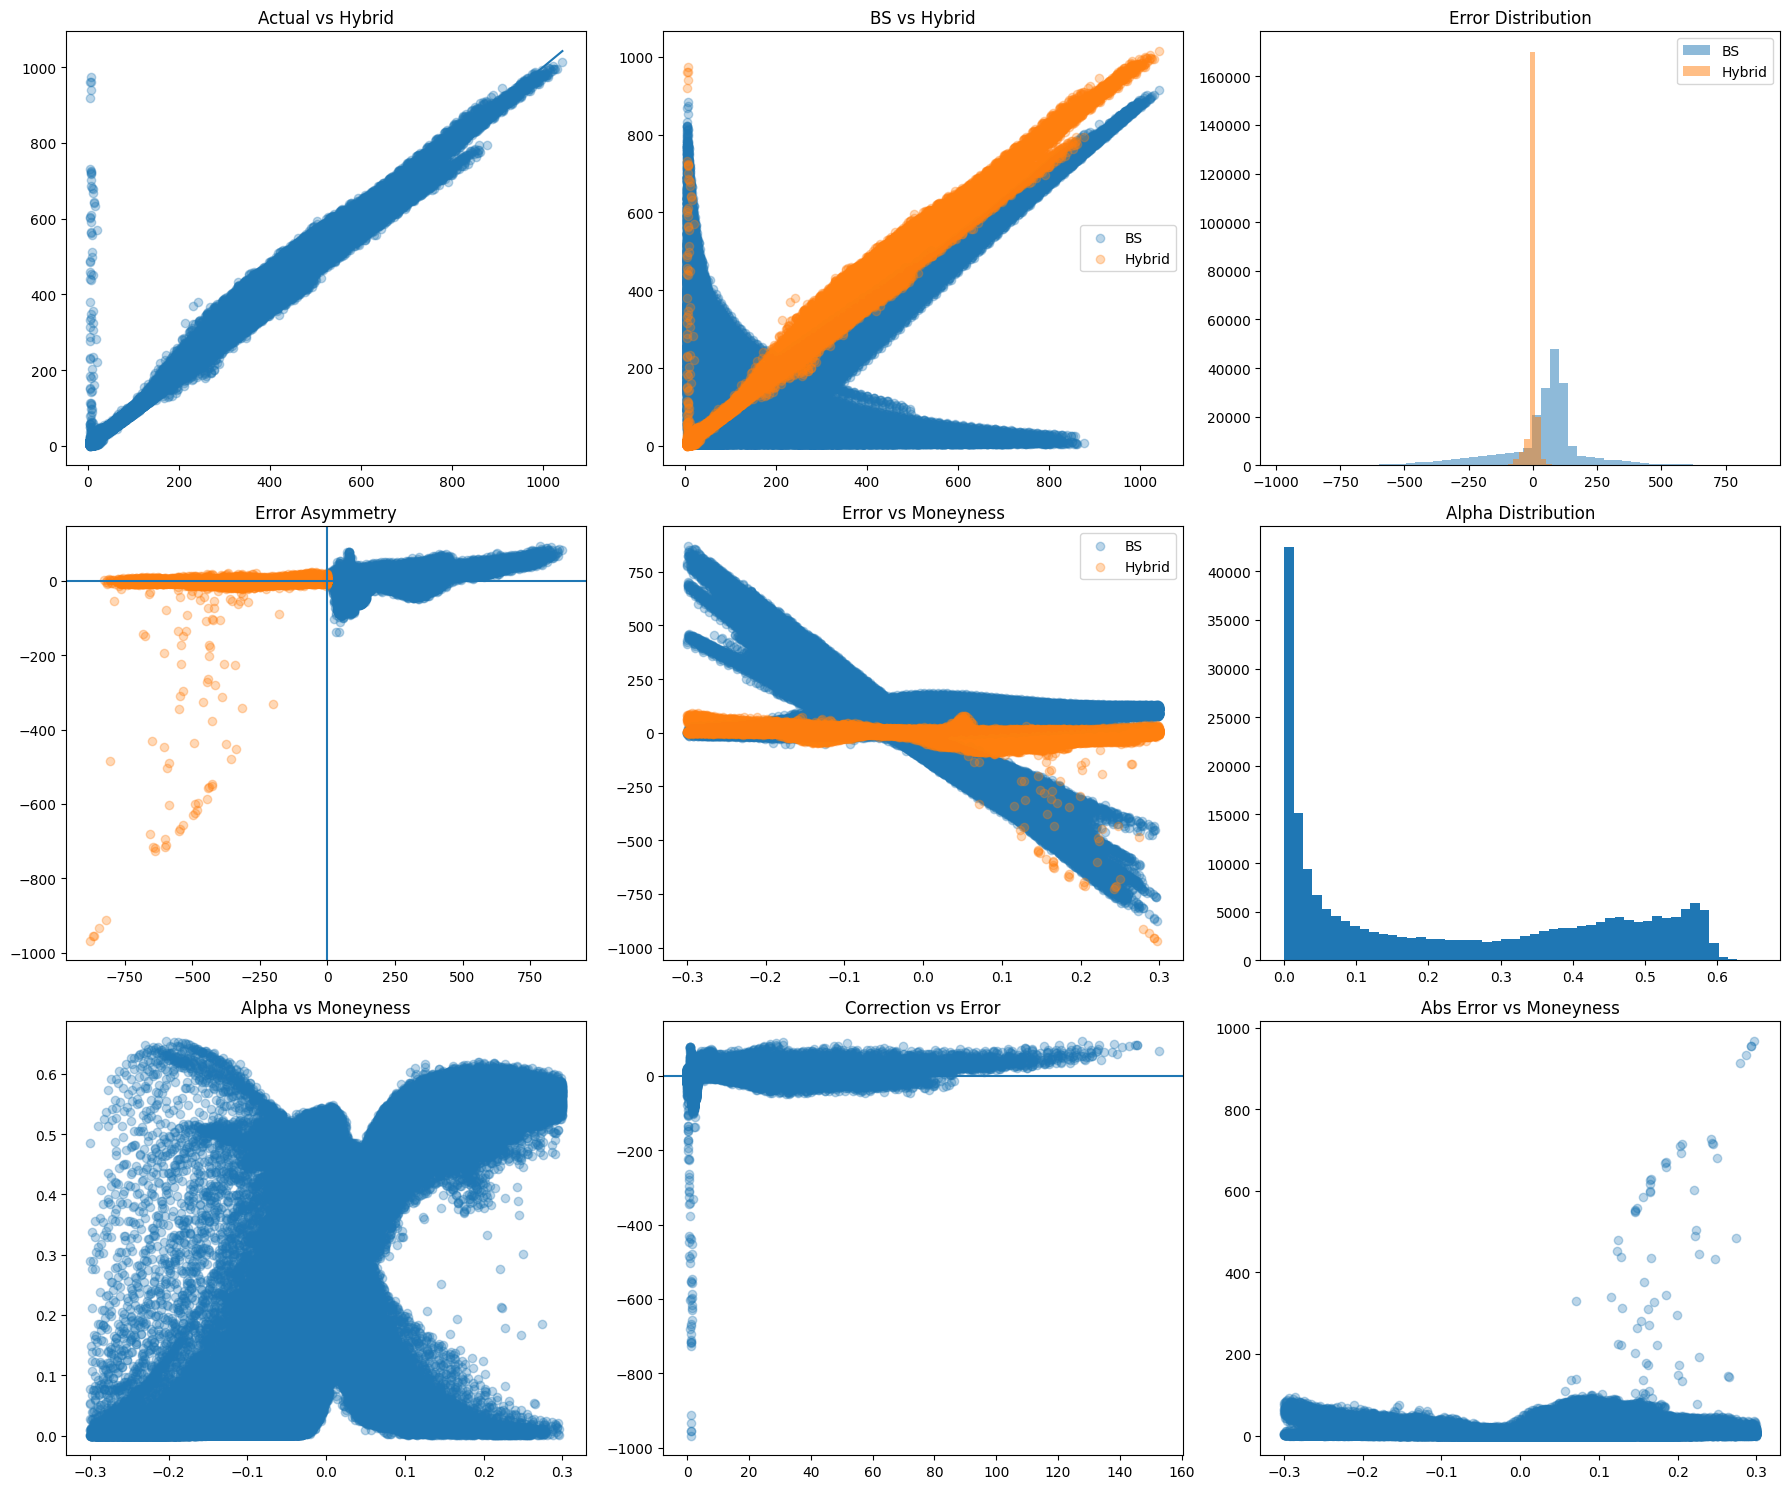

In [35]:
utils.plotting.plot_dashboard(df)

In [36]:
y = df['Market_Price'].values
h = df['hybrid_price'].values
b = df['bs_price'].values

def metrics(pred, actual):
    err = pred - actual
    return {
        'RMSE':  np.sqrt(np.mean(err**2)),
        'MAE':   np.mean(np.abs(err)),
        'MAPE%': np.mean(np.abs(err / (actual + eps))) * 100,
        'Bias':  np.mean(err),
        'MaxErr': np.max(np.abs(err)),
    }

m_h  = metrics(h, y)
m_bs = metrics(b, y)

result = pd.DataFrame([m_h, m_bs], index=['Hybrid (V3)', 'Black-Scholes']).round(4)
result['RMSE Δ%'] = ((result['RMSE'] - m_bs['RMSE']) / m_bs['RMSE'] * 100).round(1)
result['MAE  Δ%'] = ((result['MAE']  - m_bs['MAE'])  / m_bs['MAE']  * 100).round(1)
print('\n── Overall Metrics ───────────────────────────────')
print(result.to_string())
print('──────────────────────────────────────────────────')


── Overall Metrics ───────────────────────────────
                   RMSE       MAE     MAPE%     Bias    MaxErr  RMSE Δ%  MAE  Δ%
Hybrid (V3)     16.6517    7.7415    7.5843   0.5044  967.4440    -90.6    -94.0
Black-Scholes  177.3603  129.4610  370.3277 -39.3416  878.1494     -0.0      0.0
──────────────────────────────────────────────────


In [37]:
# ── By moneyness bucket
df['bucket'] = pd.cut(
    df['log_moneyness'],
    bins=[-0.3, -0.1, -0.03, 0.03, 0.1, 0.3],
    labels=['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
)

bucket_df = df.groupby('bucket', observed=True).apply(lambda g: pd.Series({
    'N':            len(g),
    'hybrid_RMSE':  np.sqrt(np.mean(g['hybrid_error']**2)),
    'bs_RMSE':      np.sqrt(np.mean(g['bs_error']**2)),
    'hybrid_MAE':   np.abs(g['hybrid_error']).mean(),
    'bs_MAE':       np.abs(g['bs_error']).mean(),
    'alpha_mean':   g['alpha'].mean(),
    'avg_Market':   g['Market_Price'].mean(),
})).round(3)
bucket_df['RMSE_improvement%'] = ((bucket_df['bs_RMSE'] - bucket_df['hybrid_RMSE'])
                                   / bucket_df['bs_RMSE'] * 100).round(1)
print('\n── By Moneyness Bucket ───────────────────────────')
print(bucket_df.to_string())



── By Moneyness Bucket ───────────────────────────
                N  hybrid_RMSE  bs_RMSE  hybrid_MAE   bs_MAE  alpha_mean  avg_Market  RMSE_improvement%
bucket                                                                                                 
Deep OTM  37666.0       16.704  255.699      11.320  181.434       0.038     203.572               93.5
OTM       45657.0        6.096  104.263       4.566   86.037       0.105     127.765               94.2
ATM       40437.0        7.639   74.172       4.434   63.980       0.313     126.373               89.7
ITM       41646.0       19.898  149.453       9.982  135.042       0.290     175.782               86.7
Deep ITM  46937.0       24.347  233.902       8.820  181.455       0.397     381.135               89.6


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


c:\Users\ARKA ROY\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


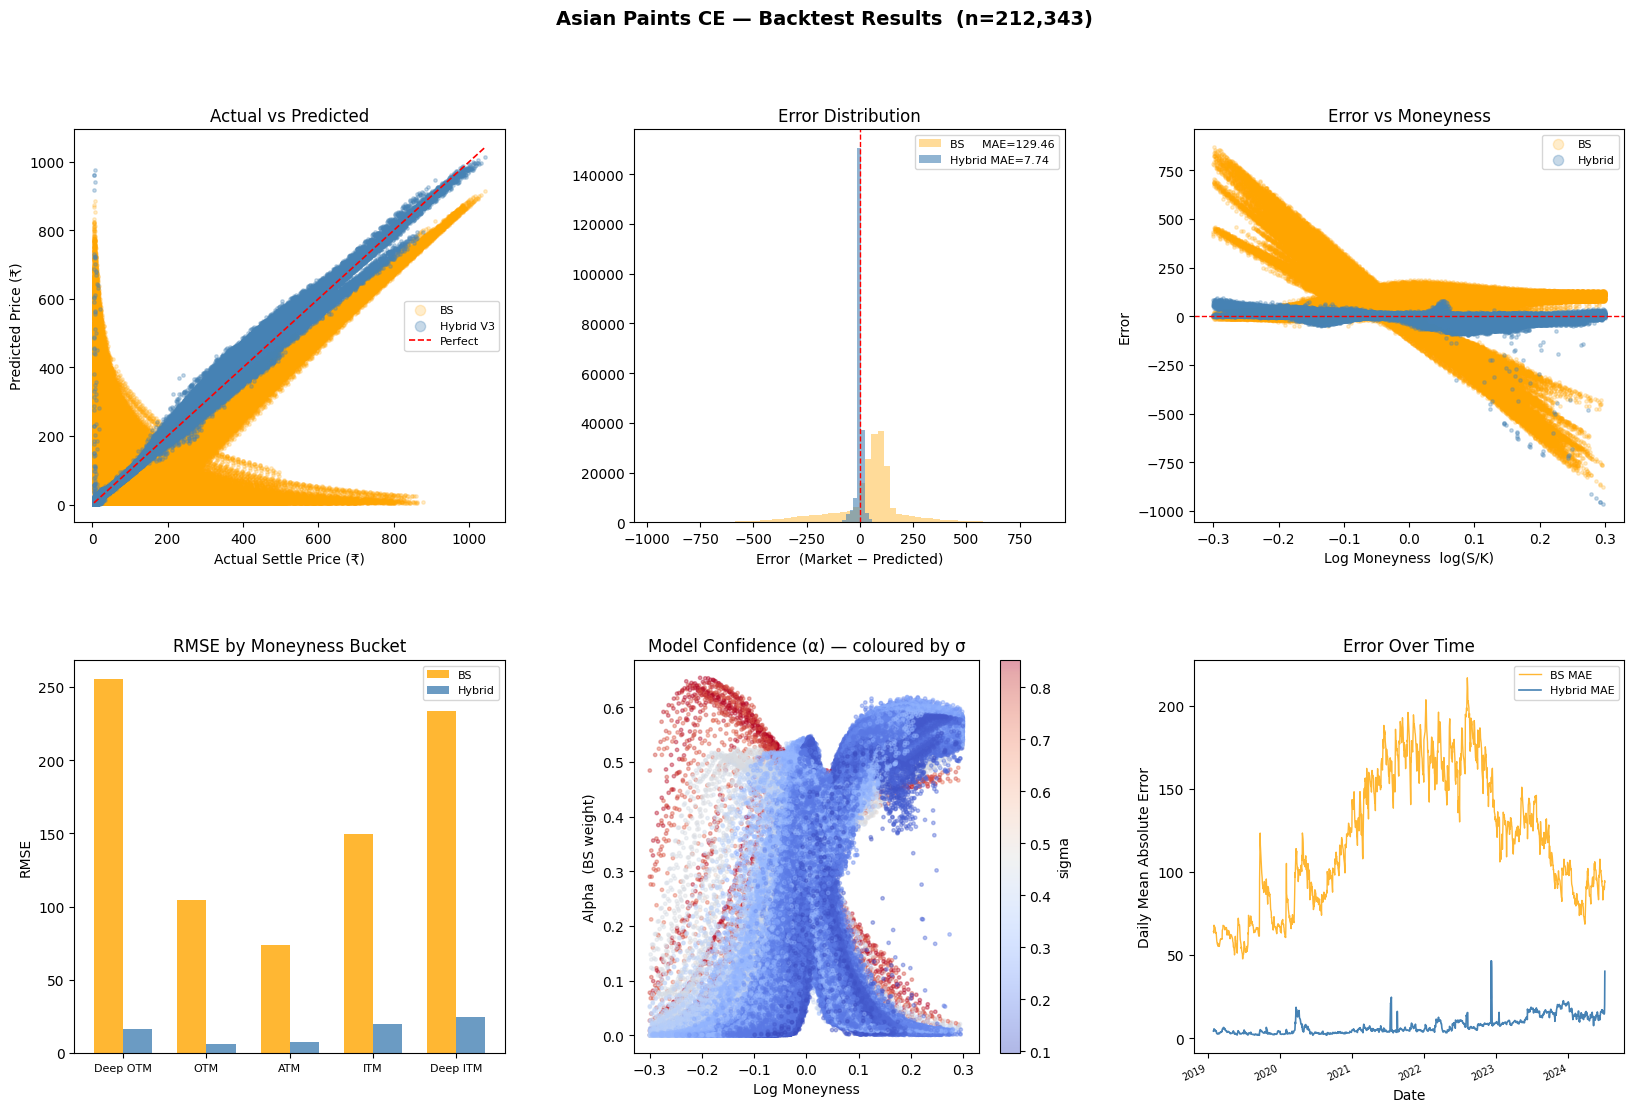

In [39]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle(f'Asian Paints CE — Backtest Results  (n={len(df):,})', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y, b, alpha=0.2, s=6, label='BS', color='orange')
ax.scatter(y, h, alpha=0.3, s=6, label='Hybrid V3', color='steelblue')
lim = [y.min(), y.max()]
ax.plot(lim, lim, 'r--', lw=1.2, label='Perfect')
ax.set_xlabel('Actual Settle Price (₹)')
ax.set_ylabel('Predicted Price (₹)')
ax.set_title('Actual vs Predicted')
ax.legend(markerscale=3, fontsize=8)

# 2. Error distribution
ax = fig.add_subplot(gs[0, 1])
ax.hist(df['bs_error'],     bins=60, alpha=0.4, label=f'BS     MAE={m_bs["MAE"]:.2f}', color='orange')
ax.hist(df['hybrid_error'], bins=60, alpha=0.6, label=f'Hybrid MAE={m_h["MAE"]:.2f}',  color='steelblue')
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Error  (Market − Predicted)')
ax.set_title('Error Distribution')
ax.legend(fontsize=8)

# 3. Error vs Log Moneyness
ax = fig.add_subplot(gs[0, 2])
ax.scatter(df['log_moneyness'], df['bs_error'],     alpha=0.2, s=6, label='BS',     color='orange')
ax.scatter(df['log_moneyness'], df['hybrid_error'], alpha=0.3, s=6, label='Hybrid', color='steelblue')
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Log Moneyness  log(S/K)')
ax.set_ylabel('Error')
ax.set_title('Error vs Moneyness')
ax.legend(markerscale=3, fontsize=8)

# 4. RMSE by moneyness bucket
ax = fig.add_subplot(gs[1, 0])
x = np.arange(len(bucket_df))
w = 0.35
ax.bar(x - w/2, bucket_df['bs_RMSE'],     w, label='BS',     color='orange',    alpha=0.8)
ax.bar(x + w/2, bucket_df['hybrid_RMSE'], w, label='Hybrid', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bucket_df.index, fontsize=8)
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Moneyness Bucket')
ax.legend(fontsize=8)

# 5. Alpha (BS weight) vs Log Moneyness
ax = fig.add_subplot(gs[1, 1])
sc = ax.scatter(df['log_moneyness'], df['alpha'], c=df['sigma'],
                cmap='coolwarm', alpha=0.4, s=6)
plt.colorbar(sc, ax=ax, label='sigma')
ax.set_xlabel('Log Moneyness')
ax.set_ylabel('Alpha  (BS weight)')
ax.set_title('Model Confidence (α) — coloured by σ')

# 6. Daily MAE over time
ax = fig.add_subplot(gs[1, 2])
daily = df.groupby('Date').agg(
    hybrid_mae=('hybrid_error', lambda x: np.abs(x).mean()),
    bs_mae    =('bs_error',     lambda x: np.abs(x).mean()),
)
ax.plot(daily.index, daily['bs_mae'],     color='orange',    lw=1,   alpha=0.8, label='BS MAE')
ax.plot(daily.index, daily['hybrid_mae'], color='steelblue', lw=1.2, label='Hybrid MAE')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean Absolute Error')
ax.set_title('Error Over Time')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=7)

# plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
# print('✓ Plot saved → backtest_results.png')

# SAVE ARTIFACTS 

In [40]:
from pathlib import Path
import pickle

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ARTIFACT = ARTIFACT_DIR / "trained_model_checkpoint.pt"
SCALER_ARTIFACT = ARTIFACT_DIR / "trained_scaler.pkl"

checkpoint = {
    "model_name": model_name,
    "state_dict": model.state_dict(),
    "features": features,
    "input_dim": len(features),
    "sigma_index": sigma_index,
    "train_size": train_size,
    "split_idx": split_idx,
    "split_date": str(split_date.date()),
    "data_file": DATA_FILE,
}

torch.save(checkpoint, MODEL_ARTIFACT)

with open(SCALER_ARTIFACT, "wb") as f:
    pickle.dump(scaler, f)

print(f"Saved model checkpoint to: {MODEL_ARTIFACT}")
print(f"Saved scaler to: {SCALER_ARTIFACT}")

Saved model checkpoint to: artifacts\trained_model_checkpoint.pt
Saved scaler to: artifacts\trained_scaler.pkl


In [41]:
checkpoint

{'model_name': 'HybridNetV3',
 'state_dict': OrderedDict([('shared.0.weight',
               tensor([[-0.0877,  0.0146, -0.0692,  ..., -0.0925,  0.0163, -0.2690],
                       [-0.4723,  0.1039, -0.0333,  ..., -0.2128, -0.0020,  0.0418],
                       [-0.0728,  0.0047, -0.1618,  ..., -0.0832, -0.2225, -0.4614],
                       ...,
                       [ 0.1887,  0.1272, -0.1384,  ...,  0.0214, -0.2676,  0.0905],
                       [ 0.0012, -0.1354,  0.2065,  ..., -0.2327, -0.0959,  0.3173],
                       [ 0.1563, -0.1769,  0.1189,  ...,  0.0331,  0.1107, -0.6270]])),
              ('shared.0.bias',
               tensor([-1.6389e-01, -2.2106e-01,  1.0119e-01,  6.0168e-03, -2.5562e-01,
                        2.0486e-01,  1.2092e-01, -2.2484e-01,  1.3194e-01, -1.1927e-01,
                       -2.6486e-01,  5.4139e-02,  4.7556e-02, -2.3515e-02,  1.5130e-01,
                       -1.1776e-01,  2.2438e-01, -2.1711e-01, -1.4241e-01, -4.7076e-0